In [1]:
# Load necessary libraries
suppressPackageStartupMessages({
    require(data.table)
    require(ggplot2)
    require(dplyr)
})
source("../utilities/functions/label-and-color-maps.R")

In [2]:
bm <- readRDS('../../data/figure-inputs/olink/MM_BMIF_Olink_Final.rds')

In [3]:
protlist <- c('CSF3','IL11','KITLG','THPO')

In [4]:
options(repr.plot.width = 18, repr.plot.height = 6)

p <- ggplot(
  bm[olink.assay %in% protlist & sample.visitDetails %in% c('PreTx', 'EI', 'ASCT90d', 'ASCT1y', 'ASCT2y')],
  aes(
    x = sample.visitDetails,
    y = olink.NPX_norm,
    group = subject.subjectGuid,
    fill = sample.visitDetails
  )
) +
  geom_line(aes(x = sample.visitDetails, y = olink.NPX_norm, group = subject.subjectGuid), alpha = 0.4) +
  geom_violin(aes(group = sample.visitDetails), alpha = 0.5) +
  geom_point(aes(color = sample.visitDetails), alpha = 0.7, size = 1.5) +
  facet_wrap(~olink.assay, scales = "free_y", ncol = 4) +
  scale_fill_manual(values = tp_color_map) +
  scale_color_manual(values = tp_color_map) +
  theme_classic(base_size = 20) +
  theme(
    text = element_text(size = 24),
    axis.text.x = element_text(size = 20, angle = 45, hjust = 1),
    axis.text.y = element_text(size = 20),
    axis.title.y = element_text(size = 20),
    strip.text = element_text(size = 20, hjust = 0, face = "bold"),
    strip.background = element_blank(),
    legend.position = "none",
    plot.title = element_text(face = "bold")
  ) +
  labs(x = "", y = "Olink NPX") +
  ggtitle("")

ggsave("../../data/figure-outputs/figure-4/fig_4g.pdf", plot = p, width = 18, height = 6, dpi = 200, device = cairo_pdf)

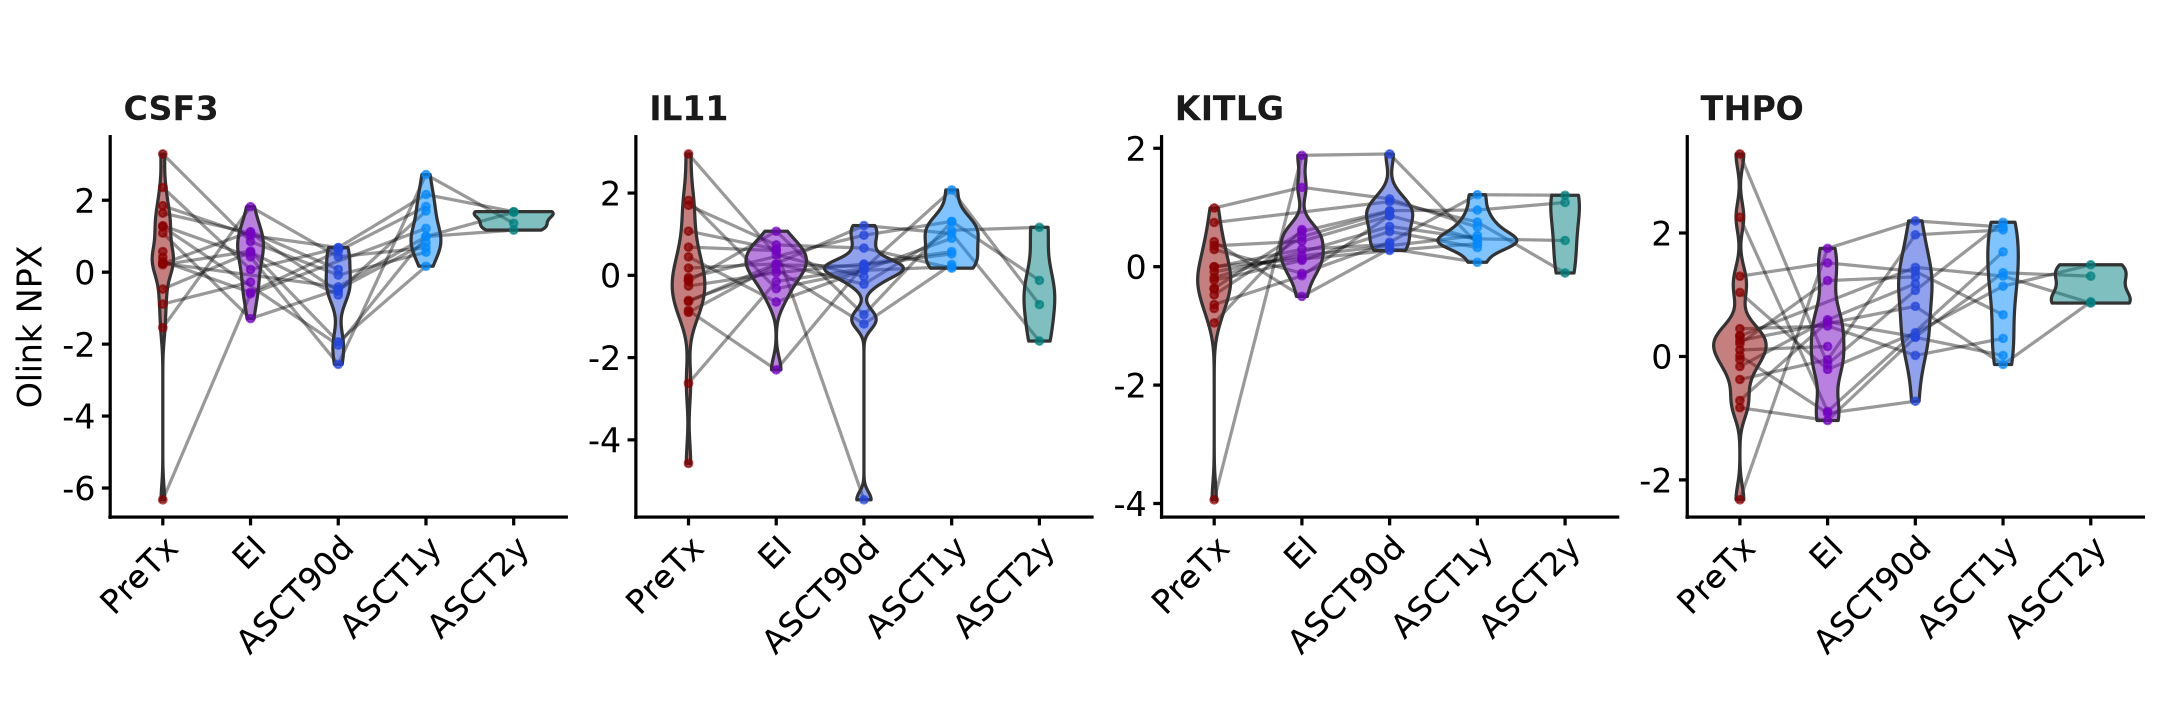

In [5]:
p